# 🫁 Chest X-Ray Classification — DenseNet121
**Dataset:** Mendeley Chest X-Ray (COVID, Normal, Pneumonia-Bacterial, Pneumonia-Viral)


In [11]:
# !pip install tensorflow scikit-learn matplotlib seaborn pandas numpy tqdm


In [12]:
# ── RESET WORKSPACE (Run ONCE before fresh start) ─────────────────────────────
import shutil, os
WORK_DIR_RESET = './densenet121_workspace'
if os.path.exists(WORK_DIR_RESET):
    shutil.rmtree(WORK_DIR_RESET)
    print(f'✅ Old workspace deleted: {WORK_DIR_RESET}')
else:
    print('ℹ️ No old workspace found — clean start')


✅ Old workspace deleted: ./densenet121_workspace


In [13]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
GPUs: []


In [14]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
DATASET_ROOT  = r'C:\Users\Admin\Desktop\dataset train\Dataset'
WORK_DIR      = './densenet121_workspace'

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE   = 30
LEARNING_RATE = 1e-4
FINE_LR       = 1e-5

TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
MODEL_NAME    = 'DenseNet121'

os.makedirs(WORK_DIR, exist_ok=True)
print('Config ready ✅')


Config ready ✅


In [15]:
# ── DATA SPLIT (resume-safe) ──────────────────────────────────────────────────
SPLIT_CSV = os.path.join(WORK_DIR, 'data_split.csv')

def build_split(dataset_root, train_r, val_r, test_r, seed):
    records = []
    dataset_root = Path(dataset_root)
    for cls_dir in sorted(dataset_root.iterdir()):
        if not cls_dir.is_dir(): continue
        label = cls_dir.name
        files = [str(p) for p in cls_dir.glob('**/*') if p.suffix.lower() in ('.jpg','.jpeg','.png')]
        for f in files:
            records.append({'filepath': f, 'label': label})
    df = pd.DataFrame(records)
    print(f'Total images: {len(df)}')
    print(df['label'].value_counts())
    train_df, tmp = train_test_split(df, test_size=(1-train_r), stratify=df['label'], random_state=seed)
    rel_val = val_r / (val_r + test_r)
    val_df, test_df = train_test_split(tmp, test_size=(1-rel_val), stratify=tmp['label'], random_state=seed)
    train_df = train_df.copy(); train_df['split'] = 'train'
    val_df   = val_df.copy();   val_df['split']   = 'val'
    test_df  = test_df.copy();  test_df['split']  = 'test'
    return pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

if os.path.exists(SPLIT_CSV):
    print('⚡ Loading saved split ...')
    df_split = pd.read_csv(SPLIT_CSV)
else:
    print('🔨 Building new split ...')
    df_split = build_split(DATASET_ROOT, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED)
    df_split.to_csv(SPLIT_CSV, index=False)
    print(f'Saved → {SPLIT_CSV}')

train_df = df_split[df_split['split']=='train'].reset_index(drop=True)
val_df   = df_split[df_split['split']=='val'].reset_index(drop=True)
test_df  = df_split[df_split['split']=='test'].reset_index(drop=True)

CLASS_NAMES = sorted(df_split['label'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
label2idx   = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
assert NUM_CLASSES == 4, f'Expected 4 classes, got {NUM_CLASSES}! Check DATASET_ROOT path.'
print('✅ Classes verified: 4 classes found')


🔨 Building new split ...
Total images: 9209
label
Normal                 3271
Pneumonia-Bacterial    3001
Pneumonia-Viral        1656
COVID                  1281
Name: count, dtype: int64
Saved → ./densenet121_workspace\data_split.csv
Train: 6446 | Val: 1381 | Test: 1382
Classes (4): ['COVID', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
✅ Classes verified: 4 classes found


In [16]:
# ── DATA GENERATORS ───────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,   # ← explicit class order fix
        shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, train_df, shuffle=True)
val_gen   = make_gen(val_test_datagen, val_df, shuffle=False)
test_gen  = make_gen(val_test_datagen, test_df, shuffle=False)

print(f'Train batches: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}')
print(f'Class indices: {train_gen.class_indices}')
assert len(train_gen.class_indices) == 4, 'Generator sees wrong number of classes!'
print('✅ Generator verified: 4 classes')


Found 6446 validated image filenames belonging to 4 classes.
Found 1381 validated image filenames belonging to 4 classes.
Found 1382 validated image filenames belonging to 4 classes.
Train batches: 202 | Val: 44 | Test: 44
Class indices: {'COVID': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
✅ Generator verified: 4 classes


In [17]:
# ── CLASS WEIGHTS ─────────────────────────────────────────────────────────────
y_train = train_df['label'].map(label2idx).values
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(cw)}
print('Class weights:', class_weights)


Class weights: {0: 1.7965440356744704, 1: 0.7040192223678462, 2: 0.7670157068062827, 3: 1.3904227782571181}


In [18]:
# ── BUILD MODEL ───────────────────────────────────────────────────────────────
def build_densenet121(num_classes, img_size):
    base = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(*img_size, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    # ✅ FIX: num_classes neurons (not 1!) + softmax for multi-class
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base

# ✅ FIX: Build AFTER NUM_CLASSES is set
model, base_model = build_densenet121(NUM_CLASSES, IMG_SIZE)

# Verify output shape
print(f'Model output shape: {model.output_shape}')  # Should be (None, 4)
assert model.output_shape[-1] == 4, f'Output neurons should be 4, got {model.output_shape[-1]}'
print('✅ Model output verified: 4 neurons')
model.summary()


Model output shape: (None, 4)
✅ Model output verified: 4 neurons


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,698,756 (29.37 MB)

 Trainable params: 659,204 (2.51 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [19]:
# ── CALLBACKS & STATE ─────────────────────────────────────────────────────────
CKPT_FROZEN = os.path.join(WORK_DIR, 'ckpt_phase1_frozen.keras')
CKPT_FINE   = os.path.join(WORK_DIR, 'ckpt_phase2_finetune.keras')
BEST_MODEL  = os.path.join(WORK_DIR, 'best_model.keras')
LOG_FROZEN  = os.path.join(WORK_DIR, 'log_phase1.csv')
LOG_FINE    = os.path.join(WORK_DIR, 'log_phase2.csv')
STATE_FILE  = os.path.join(WORK_DIR, 'train_state.json')

def get_callbacks(ckpt_path, log_path):
    return [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        CSVLogger(log_path, append=True)
    ]

def save_state(phase):
    with open(STATE_FILE, 'w') as f:
        json.dump({'completed_phase': phase}, f)

def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f:
            return json.load(f).get('completed_phase', 0)
    return 0

# ✅ FIX: Multi-class AUC (one-vs-rest)
def get_metrics():
    return [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]

completed_phase = load_state()
print(f'Resuming from completed phase: {completed_phase}')


Resuming from completed phase: 0


In [20]:
# ── PHASE 1: FROZEN BACKBONE ──────────────────────────────────────────────────
if completed_phase < 1:
    print('\n🚀 Phase 1: Training head (backbone frozen) ...')

    if os.path.exists(CKPT_FROZEN):
        print('  ↩️  Resuming from Phase-1 checkpoint ...')
        model = keras.models.load_model(CKPT_FROZEN)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FROZEN,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=get_callbacks(CKPT_FROZEN, LOG_FROZEN),
        verbose=1
    )

    save_state(1)
    print('✅ Phase 1 complete!')
else:
    print('⚡ Phase 1 already done — loading checkpoint ...')
    model = keras.models.load_model(CKPT_FROZEN)



🚀 Phase 1: Training head (backbone frozen) ...
Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5356 - auc: 0.7779 - loss: 1.2105 - precision: 0.6101 - recall: 0.3913
Epoch 1: val_accuracy improved from None to 0.76756, saving model to ./densenet121_workspace\ckpt_phase1_frozen.keras

Epoch 1: finished saving model to ./densenet121_workspace\ckpt_phase1_frozen.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 582s 3s/step - accuracy: 0.6430 - auc: 0.8710 - loss: 0.9543 - precision: 0.7214 - recall: 0.5371 - val_accuracy: 0.7676 - val_auc: 0.9439 - val_loss: 0.6992 - val_precision: 0.8404 - val_recall: 0.6597 - learning_rate: 1.0000e-04
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7473 - auc: 0.9329 - loss: 0.7028 - precision: 0.7832 - recall: 0.7026
Epoch 2: val_accuracy improved from 0.76756 to 0.80304, saving model to ./densenet121_workspace\ckpt_phase1_frozen.keras

Epoch 2: finished saving model to ./densenet121_workspace\ckpt_phase1_frozen.keras
202/202 ━━━━━

In [21]:
# ── PHASE 2: FINE-TUNING ──────────────────────────────────────────────────────
if completed_phase < 2:
    print('\n🔓 Phase 2: Fine-tuning top layers of DenseNet121 ...')

    if os.path.exists(CKPT_FINE):
        print('  ↩️  Resuming from Phase-2 checkpoint ...')
        model = keras.models.load_model(CKPT_FINE)
    else:
        # Unfreeze top dense block (denseblock4)
        for layer in model.layers:
            if hasattr(layer, 'layers'):
                for sub in layer.layers:
                    sub.trainable = ('conv5' in sub.name or 'pool5' in sub.name)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_LR),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FINE,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=get_callbacks(CKPT_FINE, LOG_FINE),
        verbose=1
    )

    save_state(2)
    shutil.copy(CKPT_FINE, BEST_MODEL)
    print('✅ Phase 2 complete!')
else:
    print('⚡ Phase 2 already done — loading best model ...')
    model = keras.models.load_model(BEST_MODEL)



🔓 Phase 2: Fine-tuning top layers of DenseNet121 ...
Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7797 - auc: 0.9510 - loss: 0.5884 - precision: 0.8076 - recall: 0.7422
Epoch 1: val_accuracy improved from None to 0.83128, saving model to ./densenet121_workspace\ckpt_phase2_finetune.keras

Epoch 1: finished saving model to ./densenet121_workspace\ckpt_phase2_finetune.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 696s 3s/step - accuracy: 0.7909 - auc: 0.9536 - loss: 0.5754 - precision: 0.8176 - recall: 0.7572 - val_accuracy: 0.8313 - val_auc: 0.9699 - val_loss: 0.4881 - val_precision: 0.8468 - val_recall: 0.8125 - learning_rate: 1.0000e-05
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8012 - auc: 0.9591 - loss: 0.5405 - precision: 0.8188 - recall: 0.7760
Epoch 2: val_accuracy did not improve from 0.83128
202/202 ━━━━━━━━━━━━━━━━━━━━ 767s 4s/step - accuracy: 0.8058 - auc: 0.9598 - loss: 0.5374 - precision: 0.8241 - recall: 0.7792 - val_accuracy: 0.8284 - val_a

In [22]:
# ── EVALUATE ON TEST SET ──────────────────────────────────────────────────────
print('\n📊 Evaluating on test set ...')
test_gen.reset()
results = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {results[0]:.4f}')
print(f'Test Accuracy : {results[1]*100:.2f}%')
print(f'Test AUC      : {results[2]:.4f}')



📊 Evaluating on test set ...
44/44 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.8531 - auc: 0.9770 - loss: 0.4285 - precision: 0.8609 - recall: 0.8423

Test Loss     : 0.4285
Test Accuracy : 85.31%
Test AUC      : 0.9770


44/44 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step

📋 Classification Report:
                     precision    recall  f1-score   support

              COVID       0.97      0.98      0.98       192
             Normal       0.93      0.99      0.96       491
Pneumonia-Bacterial       0.83      0.76      0.80       450
    Pneumonia-Viral       0.64      0.64      0.64       249

           accuracy                           0.85      1382
          macro avg       0.84      0.85      0.84      1382
       weighted avg       0.85      0.85      0.85      1382



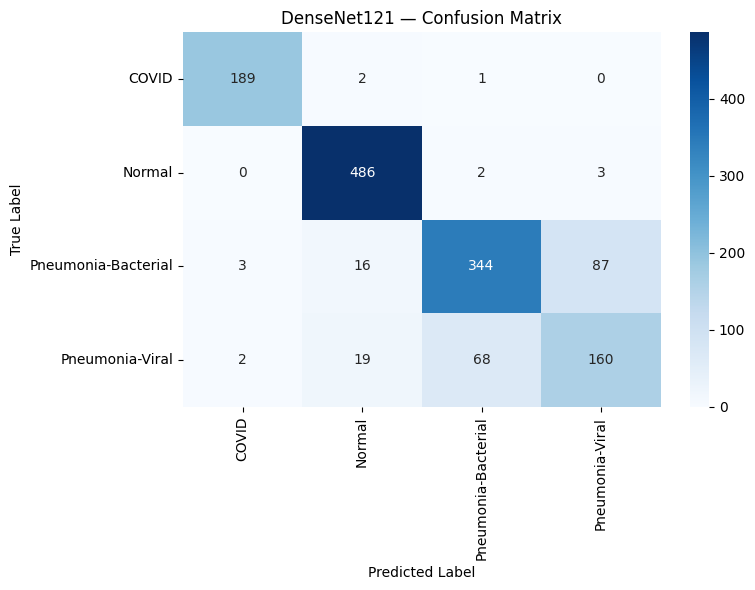

In [23]:
# ── CLASSIFICATION REPORT & CONFUSION MATRIX ──────────────────────────────────
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'{MODEL_NAME} — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()


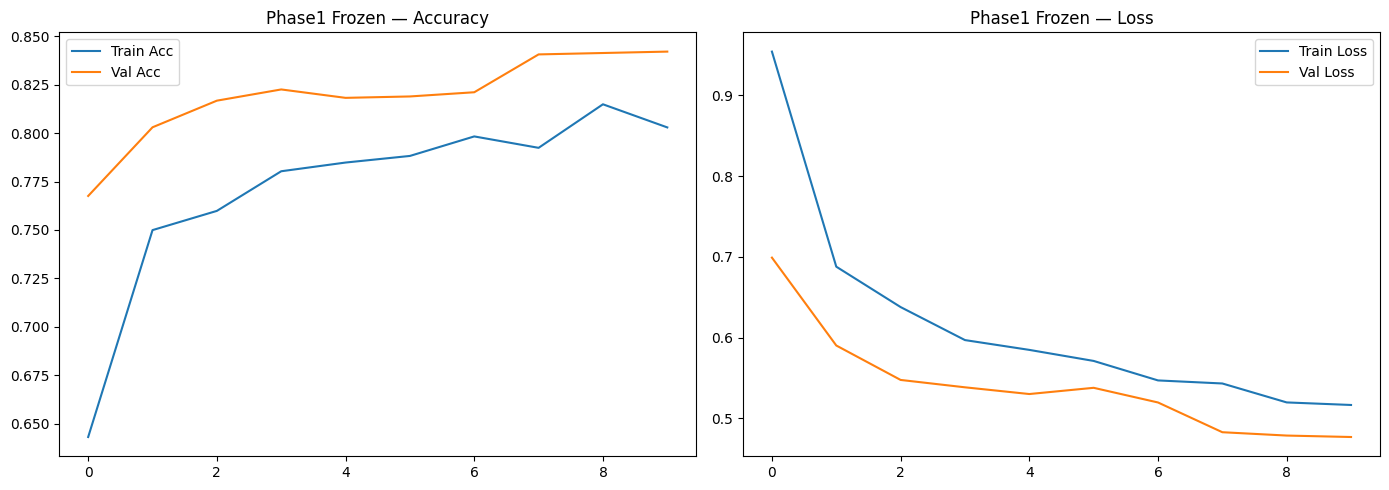

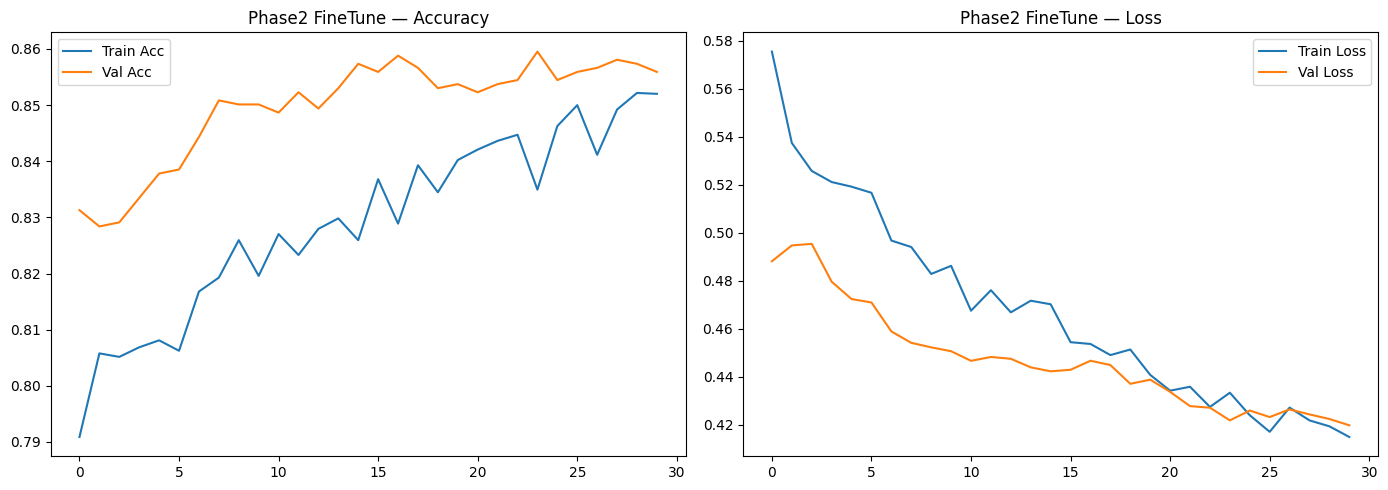

In [24]:
# ── TRAINING HISTORY PLOTS ────────────────────────────────────────────────────
def plot_history_from_csv(log_path, title):
    if not os.path.exists(log_path):
        print(f'{log_path} not found'); return
    df = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(df['accuracy'], label='Train Acc')
    axes[0].plot(df['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend()
    axes[1].plot(df['loss'], label='Train Loss')
    axes[1].plot(df['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'history_{title.replace(" ","_")}.png'), dpi=150)
    plt.show()

plot_history_from_csv(LOG_FROZEN, 'Phase1 Frozen')
plot_history_from_csv(LOG_FINE,   'Phase2 FineTune')


In [25]:
# ── SAVE FINAL MODEL ──────────────────────────────────────────────────────────
FINAL_PATH = os.path.join(WORK_DIR, f'{MODEL_NAME}_final.keras')
model.save(FINAL_PATH)
print(f'✅ Final model saved → {FINAL_PATH}')


✅ Final model saved → ./densenet121_workspace\DenseNet121_final.keras
